# ***CREDIT CARD FRAUD DETECTION***

In [2]:
###Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, make_scorer, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import NearMiss
from imblearn.under_sampling import RandomUnderSampler
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline

In [5]:
###Load DataSet
df = pd.read_csv('/content/creditcardfraud/creditcard.csv')


### **Exploratory Data Analysis (EDA)**

In [6]:
print("Data Overview:")
print(df.info())
print(df.head())

Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64


In [7]:
### Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [8]:
### Basic statistics
print("\nDataset Statistics:")
print(df.describe())


Dataset Statistics:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  

Analyze Time Feature

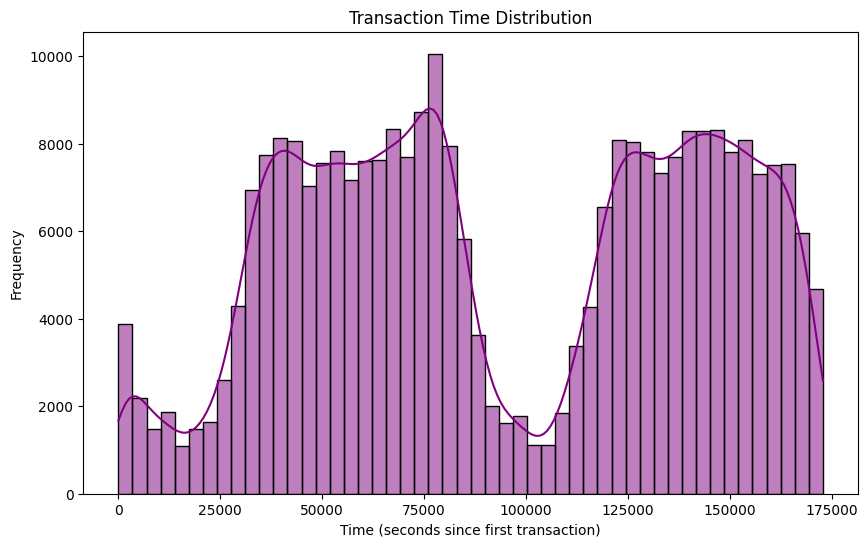

In [9]:
 ### Transaction time distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Time'], bins=50, kde=True, color='purple')
plt.title("Transaction Time Distribution")
plt.xlabel("Time (seconds since first transaction)")
plt.ylabel("Frequency")
plt.show()

Analyze Class Embalance


Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


<ipython-input-10-682df87bd7d7>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


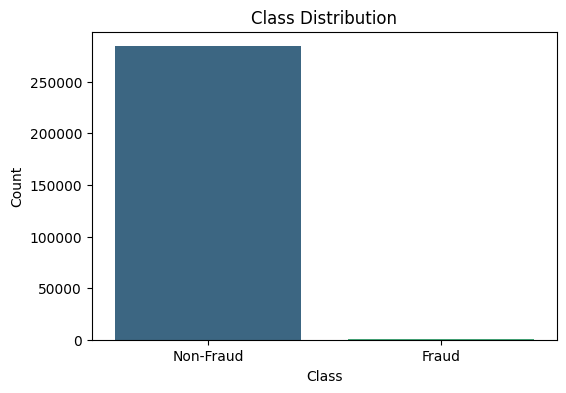

In [10]:
# Count distribution of fraud (Class 1) vs non-fraud (Class 0)
class_counts = df['Class'].value_counts()
print("\nClass Distribution:")
print(class_counts)

# Visualize class imbalance
plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.show()

Analyze Transaction Amount

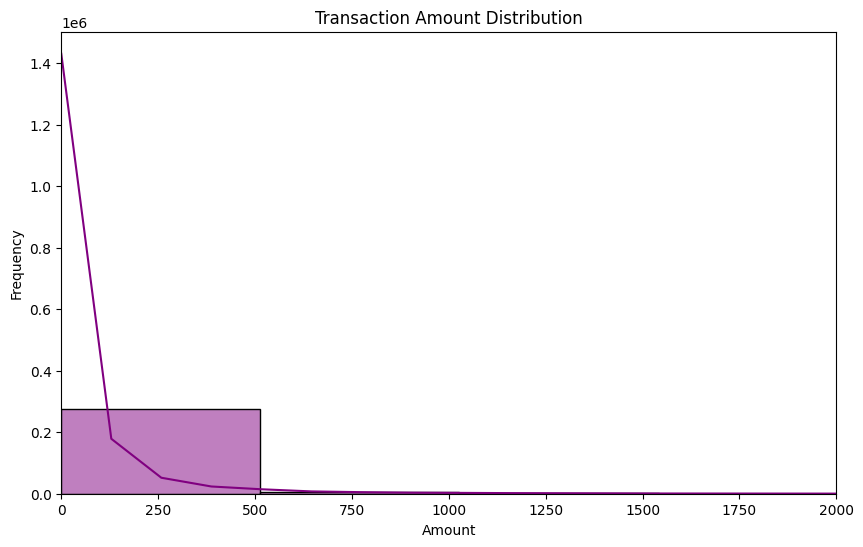

<ipython-input-11-d05def5114b4>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, palette="mako")


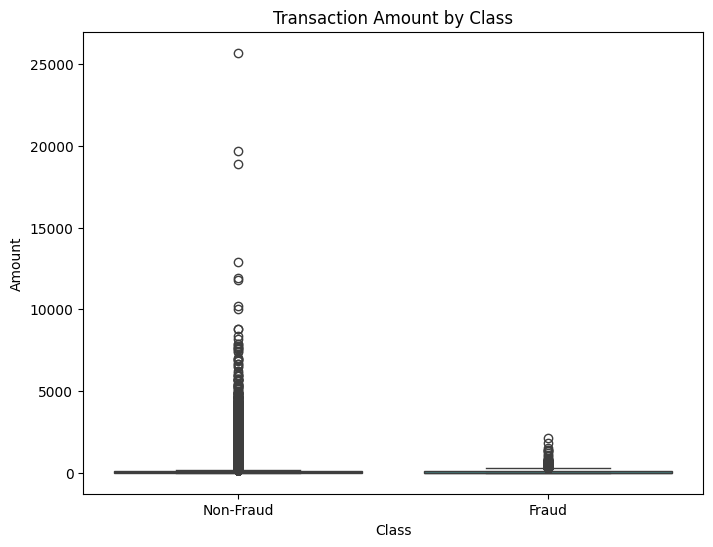

In [11]:
# Plot transaction amount distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], bins=50, kde=True, color='purple')
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.xlim(0, 2000)  # Focus on realistic range
plt.show()

# Boxplot for Fraud vs Non-Fraud Transactions
plt.figure(figsize=(8, 6))
sns.boxplot(x='Class', y='Amount', data=df, palette="mako")
plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.show()

Feature Distribution for Fraud vs Non-Fraud

<ipython-input-12-44b0fb6fcd21>:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[feature][df['Class'] == 0], label="Non-Fraud", shade=True, color="purple")
<ipython-input-12-44b0fb6fcd21>:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[feature][df['Class'] == 1], label="Fraud", shade=True, color="green")
<ipython-input-12-44b0fb6fcd21>:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[feature][df['Class'] == 0], label="Non-Fraud", shade=True, color="purple")
<ipython-input-12-44b0fb6fcd21>:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn 

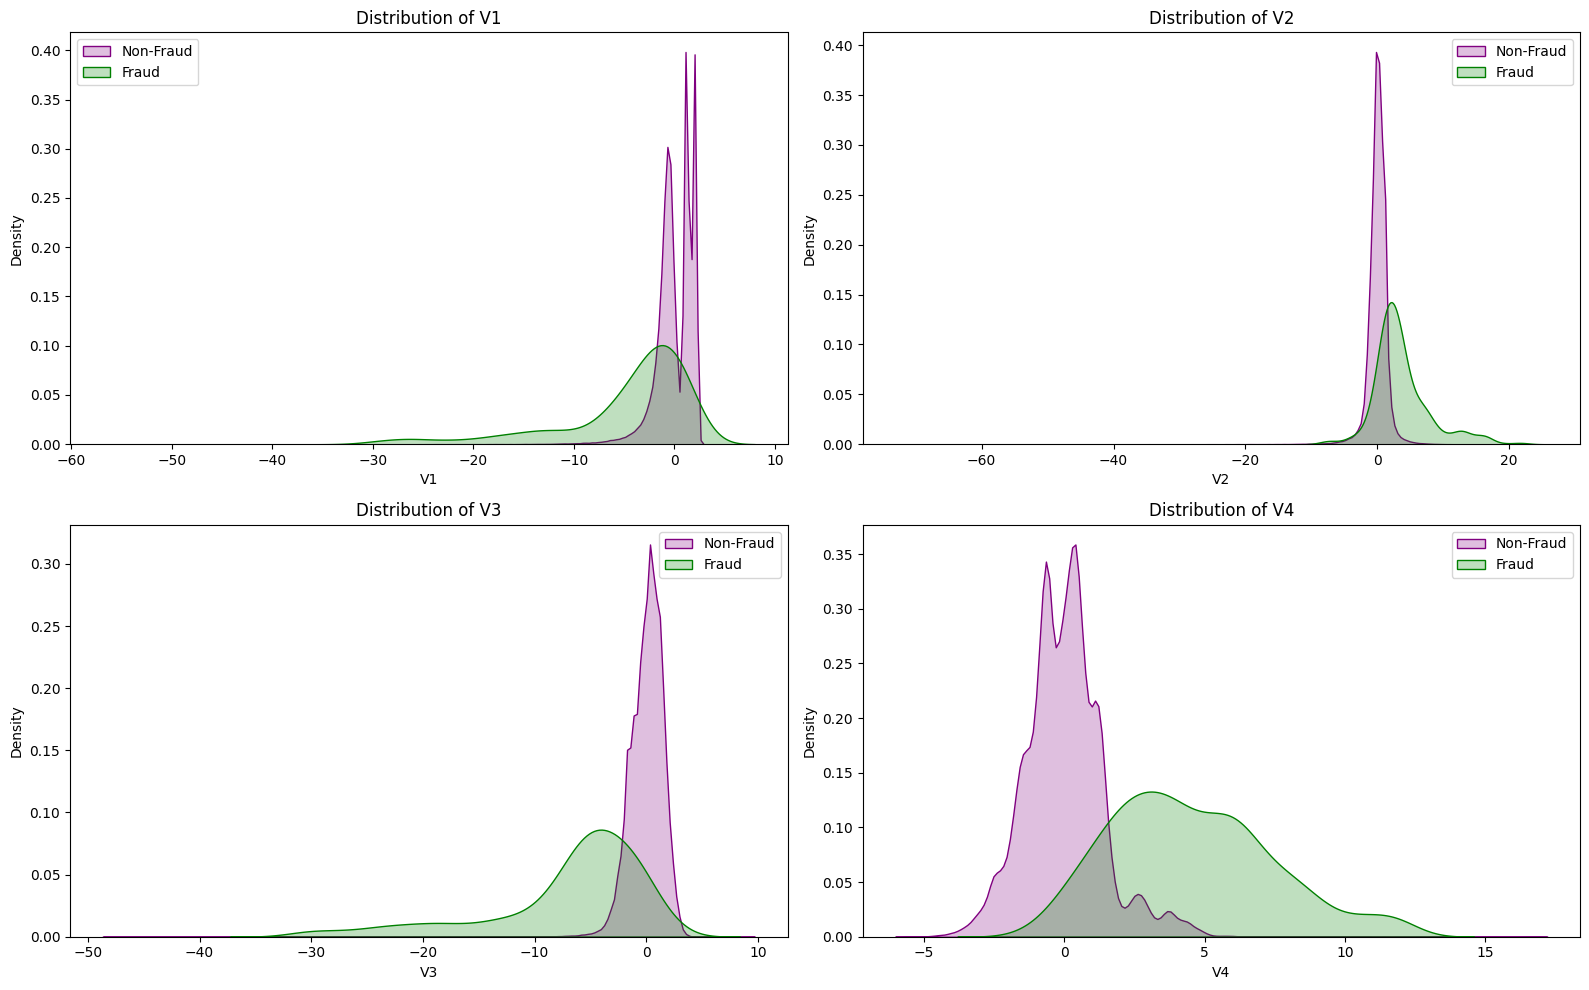

In [12]:
# Select random features for comparison
sample_features = ['V1', 'V2', 'V3', 'V4']

# Plot distributions for each feature
plt.figure(figsize=(16, 10))
for i, feature in enumerate(sample_features, 1):
    plt.subplot(2, 2, i)
    sns.kdeplot(df[feature][df['Class'] == 0], label="Non-Fraud", shade=True, color="purple")
    sns.kdeplot(df[feature][df['Class'] == 1], label="Fraud", shade=True, color="green")
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend()

plt.tight_layout()
plt.show()

# **Data Processing**

In [13]:
df = df.fillna(df.mean())


In [14]:
### Splitting the data into features and labels
X = df.drop('Class', axis=1)
y = df['Class']


In [15]:
### Stratified splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [16]:
### Scaling the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
### Apply SMOTE for balancing only on training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


# **Model Training with Hyperparameter Tuning using GridSearchCV**

In [18]:
# ### Hyperparameter tuning for Random Forest
# from sklearn.model_selection import RandomizedSearchCV

# X_train_resampled_df = pd.DataFrame(X_train_resampled)

# X_train_sampled = X_train_resampled_df.sample(frac=0.2, random_state=42)
# y_train_sampled = y_train_resampled.loc[X_train_sampled.index]

# rf_params = {
#     'n_estimators': [50,100],
#     'max_depth': [5, 10],
#     'min_samples_split': [2,5],
# }
# rf_grid = RandomizedSearchCV(
#     RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
#     rf_params,
#     n_iter=5,
#     cv=3,
#     scoring='roc_auc',
#     random_state=42
# )
# rf_grid.fit(X_train_resampled, y_train_resampled)  # Use original NumPy array for fitting
# rf_preds = rf_grid.predict(X_test)

In [19]:
# ## Hyperparameter tuning for XGBoost
# xgb_params = {
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.1],
#     'n_estimators': [50, 100],
# }
# xgb_grid = GridSearchCV(XGBClassifier(scale_pos_weight=len(y_train_resampled[y_train_resampled == 0]) /
#                                        len(y_train_resampled[y_train_resampled == 1]), random_state=42), xgb_params, cv=5, scoring='roc_auc')
# xgb_grid.fit(X_train_resampled, y_train_resampled)
# xgb_preds = xgb_grid.predict(X_test)

In [20]:
# svm_params = {
#     'C': [0.1, 1, 10],
#     'kernel': ['linear', 'rbf'],
#     'gamma': ['scale', 'auto'],
# }
# svm_grid = GridSearchCV(SVC(class_weight="balanced", probability=True, random_state=42), svm_params, cv=5, scoring='roc_auc')
# svm_grid.fit(X_train_resampled, y_train_resampled)
# svm_preds = svm_grid.predict(X_test)

## **Using Pipelining as GridSearchCV takes too much time**

In [21]:
def evaluate_model(y_true, y_proba, y_pred, model_name):
    print(f"Evaluation for {model_name}")
    print(classification_report(y_true, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_true, y_proba):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\n")

In [22]:
# Define a scoring metric (e.g., ROC-AUC)
roc_auc_scorer = make_scorer(roc_auc_score, needs_proba=True)

# Define Stratified K-Fold cross-validation
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [29]:
### Random Forest
def random_forest_pipeline(X, y):
    rf_pipeline = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
    ])
    print("\nRandom Forest Evaluation:\n")
    for train_index, test_index in stratified_kfold.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        rf_pipeline.fit(X_train, y_train)
        rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]
        rf_preds = rf_pipeline.predict(X_test)
        evaluate_model(y_test, rf_proba, rf_preds, "Random Forest (CV)")
    rf_scores = cross_val_score(rf_pipeline, X, y, cv=stratified_kfold, scoring=roc_auc_scorer)
    print(f"Random Forest Mean ROC-AUC: {np.mean(rf_scores):.4f}")

X = df.drop('Class', axis=1) # Assign the features to X by dropping the target variable
y = df['Class']

print("Model Evaluation:\n")
random_forest_pipeline(X, y)

Model Evaluation:


Random Forest Evaluation:

Evaluation for Random Forest (CV)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.85      0.80      0.82        99

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9633
Confusion Matrix:
[[56849    14]
 [   20    79]]


Evaluation for Random Forest (CV)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.93      0.86      0.89        99

    accuracy                           1.00     56962
   macro avg       0.97      0.93      0.95     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9711
Confusion Matrix:
[[56857     6]
 [   14    85]]


Evaluation for Random Forest (CV)
              precision    recall  f1-score   support

        

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/inspect.py", line 3195, in bind
    return self._bind(args, kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/inspect.

Random Forest Mean ROC-AUC: nan


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/inspect.py", line 3195, in bind
    return self._bind(args, kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/inspect.

In [28]:
# XGBoost Pipeline with Stratified K-Fold Cross-Validation and Evaluation
import warnings

def xgboost_pipeline(X, y):
    xgb_pipeline = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', XGBClassifier(eval_metric='logloss', random_state=42))
    ])
    print("\nXGBoost Evaluation:\n")

    for train_index, test_index in stratified_kfold.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")  # Ignore all warnings
            xgb_pipeline.fit(X_train, y_train)

        xgb_proba = xgb_pipeline['model'].predict_proba(X_test)[:, 1]
        xgb_preds = xgb_pipeline['model'].predict(X_test)

        evaluate_model(y_test, xgb_proba, xgb_preds, "XGBoost")

    # Cross-Validation Scores (with warning suppression)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        xgb_scores = cross_val_score(xgb_pipeline, X, y, cv=stratified_kfold, scoring=roc_auc_scorer)

    print(f"XGBoost Mean ROC-AUC: {np.mean(xgb_scores):.4f}")

xgboost_pipeline(X, y)


XGBoost Evaluation:

Evaluation for XGBoost
              precision    recall  f1-score   support

           0       1.00      0.60      0.75     56863
           1       0.00      0.90      0.01        99

    accuracy                           0.60     56962
   macro avg       0.50      0.75      0.38     56962
weighted avg       1.00      0.60      0.75     56962

ROC-AUC: 0.9059
Confusion Matrix:
[[34208 22655]
 [   10    89]]


Evaluation for XGBoost
              precision    recall  f1-score   support

           0       1.00      0.56      0.72     56863
           1       0.00      0.90      0.01        99

    accuracy                           0.56     56962
   macro avg       0.50      0.73      0.36     56962
weighted avg       1.00      0.56      0.72     56962

ROC-AUC: 0.9127
Confusion Matrix:
[[31788 25075]
 [   10    89]]


Evaluation for XGBoost
              precision    recall  f1-score   support

           0       1.00      0.56      0.72     56863
           1

In [23]:
# ### SVM Pipeline
# def svm_pipeline_func(X, y):
#     svm_pipeline = Pipeline([
#         ('smote', SMOTE(random_state=42)),
#         ('scaler', StandardScaler()),
#         ('model', SVC(class_weight='balanced', probability=True, random_state=42))
#     ])

#     # Stratified K-Fold Manual Evaluation
#     for train_index, test_index in stratified_kfold.split(X, y):
#         X_train, X_test = X.iloc[train_index], X.iloc[test_index]
#         y_train, y_test = y.iloc[train_index], y.iloc[test_index]

#         svm_pipeline.fit(X_train, y_train)
#         svm_proba = svm_pipeline.predict_proba(X_test)[:, 1]
#         svm_preds = svm_pipeline.predict(X_test)

#         evaluate_model(y_test, svm_proba, svm_preds, "SVM")

#     # Cross-Validation Scores
#     svm_scores = cross_val_score(svm_pipeline, X, y, cv=stratified_kfold, scoring=roc_auc_scorer)
#     print(f"SVM Mean ROC-AUC: {np.mean(svm_scores):.4f}")

# svm_pipeline_func(X,y)



# **Exploring Alternative Imbalance Methods**

**1.In-Algorithm Techniques**

Random Forest and XGBoost: class_weight / scale_pos_weight

In [24]:
# Random Forest with class_weight
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)  # Original data (no SMOTE applied here)
rf_preds = rf_model.predict(X_test)


print(f"Evaluation for Random Forest (In-Algorithm")
print(classification_report(y_test, rf_preds))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_preds):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_preds))
print("\n")

Evaluation for Random Forest (In-Algorithm
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.8724

Confusion Matrix:
[[56861     3]
 [   25    73]]




In [25]:
# XGBoost: scale_pos_weight

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)


print(f"Evaluation for XGBoost (In-Algorithm)")
print(classification_report(y_test, xgb_preds))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_preds):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_preds))
print("\n")

Evaluation for XGBoost (In-Algorithm)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9183

Confusion Matrix:
[[56853    11]
 [   16    82]]




**2. Under-Sampling Techniques**


In [26]:
# Apply NearMiss under-sampling
nm = NearMiss()
X_train_resampled, y_train_resampled = nm.fit_resample(X_train, y_train)

# Train Random Forest on under-sampled data
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)
rf_preds = rf_model.predict(X_test)

print(f"Evaluation for Random Forest (Under-Sampling with NearMiss)")
print(classification_report(y_test, rf_preds))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_preds):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_preds))
print("\n")

Evaluation for Random Forest (Under-Sampling with NearMiss)
              precision    recall  f1-score   support

           0       1.00      0.04      0.07     56864
           1       0.00      0.99      0.00        98

    accuracy                           0.04     56962
   macro avg       0.50      0.51      0.04     56962
weighted avg       1.00      0.04      0.07     56962

ROC-AUC: 0.5125

Confusion Matrix:
[[ 2001 54863]
 [    1    97]]




In [27]:

# Apply random under-sampling
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)
rf_preds = rf_model.predict(X_test)


print(f"Evaluation for Random Forest (Random Under-Sampling)")
print(classification_report(y_test, rf_preds))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_preds):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_preds))
print("\n")

Evaluation for Random Forest (Random Under-Sampling)
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.92      0.08        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962

ROC-AUC: 0.9413

Confusion Matrix:
[[54828  2036]
 [    8    90]]


